In [13]:
from statsmodels.tsa.stattools import acf, pacf, ccf
import pickle
import numpy as np
import matplotlib.pyplot as plt

In [30]:
def sliding_window_average(data, window_size):
    """
    Compute sliding window average using numpy.convolve
    
    Parameters:
    data (array-like): Input data
    window_size (int): Size of the sliding window
    
    Returns:
    numpy.ndarray: Sliding window averages
    """
    window = np.ones(window_size) / window_size
    return np.convolve(data, window, mode='valid')

def trim_leading_values(data, value=0):
    """
    Trims leading values that match the specified value from each series in a 2D array.
    
    Args:
        data: 2D numpy array where each row is a series
        value: The value to trim from the beginning of each series (default is 0)
        
    Returns:
        2D numpy array with all series aligned from their first non-matching element
    """
    # Find the first index that doesn't match the specified value for each series
    first_nonmatching = np.argmax(data != value, axis=1)
    
    # If a series is all matching values, argmax returns 0, so we need to check and fix this
    for i in range(len(first_nonmatching)):
        if first_nonmatching[i] == 0 and data[i, 0] == value:
            # If the first element matches the value and argmax returned 0,
            # it means the series might be all matching values
            if np.all(data[i] == value):
                first_nonmatching[i] = len(data[i])  # Set to length of series
    
    # Find the earliest starting point across all series
    min_start = np.min(first_nonmatching)
    
    # If min_start is the length of the series, all values match in at least one series
    if min_start >= data.shape[1]:
        return np.empty((data.shape[0], 0))  # Return empty array with correct first dimension
    
    # Prepare result array
    result = []
    
    # For each series, slice from its first non-matching element
    for i, start_idx in enumerate(first_nonmatching):
        # Shift the series to align with the earliest starting point
        shift = start_idx - min_start
        
        # Create a new series with the specified value for padding at the beginning if needed
        new_series = np.full(data.shape[1] - min_start, value)
        
        # Only copy the non-matching part of the original series
        if start_idx < data.shape[1]:  # Check if there are any non-matching elements
            if shift >= 0:
                new_series[shift:] = data[i, start_idx:]
            else:
                # This case shouldn't happen given how min_start is calculated
                # but included for completeness
                new_series[:] = data[i, start_idx:start_idx+len(new_series)]
        
        result.append(new_series)
    
    return np.array(result)

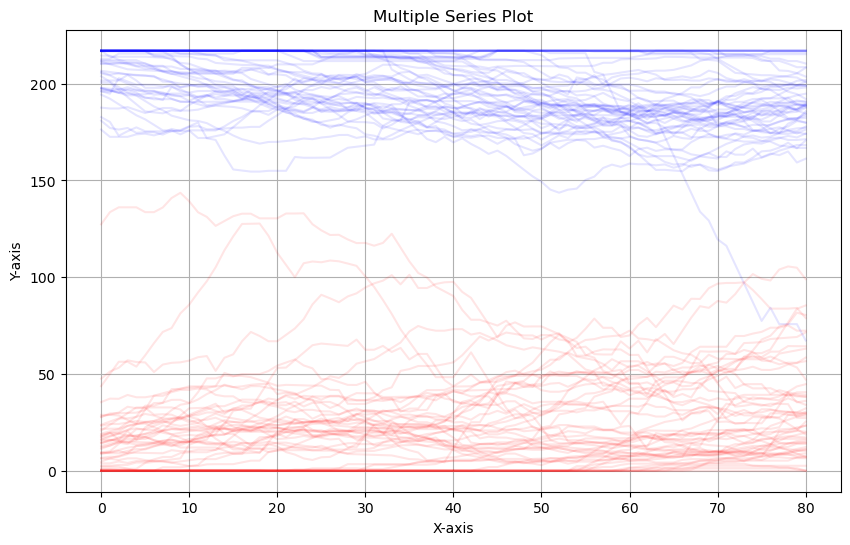

In [ ]:
# load data
with open ('data/categorized/interactions-150-180-100ns.pickle', 'rb') as f:
    data = pickle.load(f)

# convert data to numbers by z axis
with open(f"data/anchor_coordinates.pickle", "rb") as f:
    anchor_coordinates = pickle.load(f)
anchor_coordinates = dict(sorted(anchor_coordinates.items(), key=lambda x: x[1][2]))
new_states = ["nuc"] + list(anchor_coordinates.keys()) + ["cyt"]
state_to_index = {state: i for i, state in enumerate(new_states)}
vectorized_lookup = np.vectorize(lambda x: state_to_index.get(x, 0))  # 0 is default if key not found
data = vectorized_lookup(data)

plt.figure(figsize=(10, 6))
window_size = 20
x = np.arange(data.shape[1] - window_size + 1)

# Filter the array to only keep rows that start with 0 and are not all zeros
starts_with_zero_mask = data[:, 0] == 0
not_all_zeros_mask = np.any(data != 0, axis=1)
final_mask = starts_with_zero_mask & not_all_zeros_mask
nuc_data = data[final_mask]
# nuc_data = trim_leading_values(nuc_data, value=0)

# Randomly keep 20
selected_indices = np.random.choice(nuc_data.shape[0], size=50, replace=False)
nuc_data = nuc_data[selected_indices]

for i in range(nuc_data.shape[0]):
    y = sliding_window_average(nuc_data[i], window_size=window_size)
    plt.plot(x, y, label=f'Series {i+1}', color="red", alpha=0.1)
    
# Filter the array to only keep rows that start with 0 and are not all zeros
starts_with_zero_mask = data[:, 0] == 217
not_all_zeros_mask = np.any(data != 217, axis=1)
final_mask = starts_with_zero_mask & not_all_zeros_mask
cyt_data = data[final_mask]
# cyt_data = trim_leading_values(cyt_data, value=0)

# Randomly keep 20
selected_indices = np.random.choice(cyt_data.shape[0], size=50, replace=False)
cyt_data = cyt_data[selected_indices]

for i in range(cyt_data.shape[0]):
    y = sliding_window_average(cyt_data[i], window_size=window_size)
    plt.plot(x, y, label=f'Series {i+1}', color="blue", alpha=0.1)

plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Multiple Series Plot')
# plt.legend()
plt.grid(True)
plt.show()






In [ ]:
# load data
with open ('data/categorized/interactions-150-180-100ns.pickle', 'rb') as f:
    data = pickle.load(f)

# convert data to numbers by z axis
with open(f"data/anchor_coordinates.pickle", "rb") as f:
    anchor_coordinates = pickle.load(f)
anchor_coordinates = dict(sorted(anchor_coordinates.items(), key=lambda x: x[1][2]))
new_states = ["nuc"] + list(anchor_coordinates.keys()) + ["cyt"]
state_to_index = {state: i for i, state in enumerate(new_states)}
vectorized_lookup = np.vectorize(lambda x: state_to_index.get(x, 0))  # 0 is default if key not found
data = vectorized_lookup(data)


import warnings

with warnings.catch_warnings():

    # Calculate the ACF for each time series in the data
    pacf_data = np.zeros((len(data), 11))
    for i in range(len(data)):
        pacf_data[i] = pacf(data[i], nlags=10) 

    print(np.mean(pacf_data, axis=0))
    
# [ 1.00000000e+00  1.80343381e-01  8.23921863e-02  5.92711279e-02
#   2.94943512e-02  2.84049366e-02  1.11523424e-02  1.42982023e-02
#   7.58809928e-04  6.92080488e-03 -5.49731157e-03]